# ICBHI 2017 — Preprocessing Pipeline

Preprocesses the ICBHI respiratory sound database for lung disease classification using 3-channel mel spectrograms.

**Class grouping (5 classes):** Following Kiirala et al. (2024) and standard practice in ICBHI literature, we merge clinically similar diseases to handle the severe class imbalance:

| Class | Original diseases | Patients | Rationale |
|---|---|---|---|
| COPD | COPD | 64 | Dominant class, kept as-is |
| Healthy | Healthy | 26 | Control group |
| Resp. Infection | URTI + LRTI | 16 | Both are respiratory tract infections |
| Other Chronic | Bronchiectasis + Bronchiolitis + Asthma | 14 | Chronic airway diseases with similar auscultation patterns |
| Pneumonia | Pneumonia | 6 | Distinct pathology, sufficient samples |

**Solutions applied to dataset problems:**
- Audio-level oversampling for minority classes (generates realistic training variants)
- Per-equipment normalization (removes device fingerprint from spectrograms)
- 3-channel spectrograms: mel + delta + delta-delta (captures temporal dynamics)
- SpecAugment, Mixup, balanced batching, and weighted loss (all in the training notebook)

---
## 0 — Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install librosa soundfile -q

In [3]:
import os, json, time
import numpy as np
import pandas as pd
import librosa
import librosa.display
import soundfile as sf
import matplotlib.pyplot as plt
import warnings
from collections import Counter, defaultdict
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings('ignore')
np.random.seed(42)
print('Imports done.')

Imports done.


In [6]:
# ---- paths (change these to match your drive) ----
DATA_DIR      = '/content/drive/MyDrive/ICBHI_dataset/'
DIAGNOSIS_CSV = '/content/drive/MyDrive/ICBHI_dataset/patient_diagnosis.csv'
OUTPUT_DIR    = '/content/drive/MyDrive/ICBHI_preprocessed/'

# ---- spectrogram settings ----
TARGET_SR      = 16000    # everything resampled to 16 kHz
N_MELS         = 128
N_FFT          = 1024
HOP_LENGTH     = 512
F_MIN          = 50       # skip low-frequency rumble
F_MAX          = 2000     # cap at 2 kHz so Litt3200 (4kHz native) doesn't look different
CYCLE_DURATION = None     # we'll figure this out from the data

# ---- oversampling target ----
# any class with fewer training cycles than this gets audio-augmented up to this number
MIN_CYCLES_PER_CLASS = 300

# ---- split ratios ----
TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15
RANDOM_SEED = 42

# ---- class grouping (following Kiirala et al. 2024) ----
# merges clinically similar diseases so every class has enough patients
CLASS_GROUPING = {
    'COPD':           'COPD',
    'Healthy':        'Healthy',
    'URTI':           'Resp. Infection',
    'LRTI':           'Resp. Infection',
    'Bronchiectasis': 'Other Chronic',
    'Bronchiolitis':  'Other Chronic',
    'Asthma':         'Other Chronic',
    'Pneumonia':      'Pneumonia',
}

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f'Output: {OUTPUT_DIR}')
print(f'Target SR: {TARGET_SR} Hz | fmax: {F_MAX} Hz')
print(f'Classes: {sorted(set(CLASS_GROUPING.values()))}')

Output: /content/drive/MyDrive/ICBHI_preprocessed/
Target SR: 16000 Hz | fmax: 2000 Hz
Classes: ['COPD', 'Healthy', 'Other Chronic', 'Pneumonia', 'Resp. Infection']


---
## 1 — Load metadata and apply class grouping

In [7]:
# load the diagnosis file
diagnosis_df = pd.read_csv(DIAGNOSIS_CSV, header=None, names=['patient_id', 'diagnosis'])
diagnosis_df['diagnosis'] = diagnosis_df['diagnosis'].str.strip()

# map each patient to their grouped class
diagnosis_df['class'] = diagnosis_df['diagnosis'].map(CLASS_GROUPING)
diagnosis_map = dict(zip(diagnosis_df['patient_id'], diagnosis_df['diagnosis']))
class_map = dict(zip(diagnosis_df['patient_id'], diagnosis_df['class']))

print(f'Total patients: {len(diagnosis_df)}')
print(f'\nOriginal 8 classes → grouped into 5:')
for grp, sub in diagnosis_df.groupby('class'):
    orig = sub['diagnosis'].value_counts().to_dict()
    print(f'  {grp:20s}: {len(sub):3d} patients  ← {orig}')

Total patients: 126

Original 8 classes → grouped into 5:
  COPD                :  64 patients  ← {'COPD': 64}
  Healthy             :  26 patients  ← {'Healthy': 26}
  Other Chronic       :  14 patients  ← {'Bronchiectasis': 7, 'Bronchiolitis': 6, 'Asthma': 1}
  Pneumonia           :   6 patients  ← {'Pneumonia': 6}
  Resp. Infection     :  16 patients  ← {'URTI': 14, 'LRTI': 2}


In [8]:
# find all wav/txt pairs and parse the filenames
wav_files = sorted([f for f in os.listdir(DATA_DIR) if f.endswith('.wav')])
txt_set = set(f for f in os.listdir(DATA_DIR) if f.endswith('.txt'))

recordings = []
for wf in wav_files:
    base = wf.replace('.wav', '')
    tf = base + '.txt'
    if tf not in txt_set:
        continue
    parts = base.split('_')
    pid = int(parts[0])
    recordings.append({
        'wav_file': wf, 'txt_file': tf, 'base_name': base,
        'patient_id': pid, 'rec_index': parts[1], 'chest_loc': parts[2],
        'acq_mode': parts[3], 'equipment': parts[4],
        'original_dx': diagnosis_map.get(pid, 'Unknown'),
        'disease_class': class_map.get(pid, 'Unknown'),
    })

rec_df = pd.DataFrame(recordings)
print(f'Matched recordings: {len(rec_df)}')
print(f'\nEquipment:')
for eq, cnt in rec_df['equipment'].value_counts().items():
    print(f'  {eq:15s}: {cnt}')

Matched recordings: 920

Equipment:
  AKGC417L       : 646
  Meditron       : 127
  LittC2SE       : 87
  Litt3200       : 60


---
## 2 — Figure out cycle durations and pick a padding target

In [9]:
def parse_annotation(txt_path):
    """read an ICBHI annotation file and return a list of cycle dicts"""
    cycles = []
    with open(txt_path) as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split('\t') if '\t' in line else line.split()
            if len(parts) >= 4:
                cycles.append({
                    'start': float(parts[0]), 'end': float(parts[1]),
                    'crackle': int(parts[2]), 'wheeze': int(parts[3])
                })
    return cycles

# scan all annotations to get cycle stats
all_durations = []
cycles_per_class = defaultdict(int)

for _, row in tqdm(rec_df.iterrows(), total=len(rec_df), desc='Reading annotations'):
    for c in parse_annotation(os.path.join(DATA_DIR, row['txt_file'])):
        dur = c['end'] - c['start']
        all_durations.append(dur)
        cycles_per_class[row['disease_class']] += 1

all_durations = np.array(all_durations)

# pick padding target from the 95th percentile, rounded up
p95 = np.percentile(all_durations, 95)
CYCLE_DURATION = np.ceil(p95 * 2) / 2

print(f'\nTotal cycles: {len(all_durations)}')
print(f'Duration P50={np.median(all_durations):.2f}s, P95={p95:.2f}s, max={all_durations.max():.2f}s')
print(f'→ padding target: {CYCLE_DURATION}s (covers {100*np.mean(all_durations <= CYCLE_DURATION):.1f}% without truncation)')

print(f'\nCycles per class (before any augmentation):')
for cls, cnt in sorted(cycles_per_class.items(), key=lambda x: -x[1]):
    marker = ' ← needs augmentation' if cnt < MIN_CYCLES_PER_CLASS else ''
    print(f'  {cls:20s}: {cnt:5d}{marker}')

Reading annotations: 100%|██████████| 920/920 [04:18<00:00,  3.56it/s]


Total cycles: 6898
Duration P50=2.54s, P95=4.59s, max=16.16s
→ padding target: 5.0s (covers 96.6% without truncation)

Cycles per class (before any augmentation):
  COPD                :  5746
  Healthy             :   322
  Pneumonia           :   285 ← needs augmentation
  Resp. Infection     :   275 ← needs augmentation
  Other Chronic       :   270 ← needs augmentation


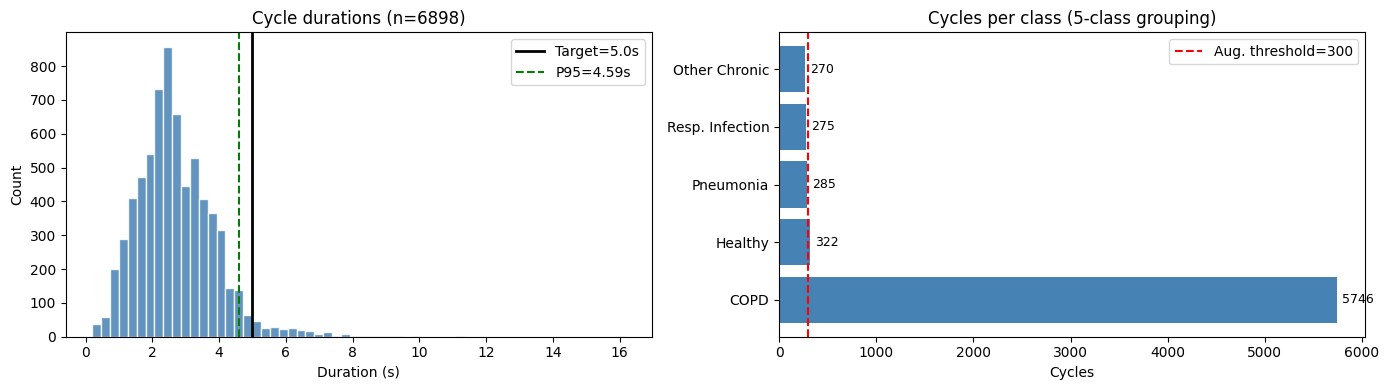

In [10]:
# plot the duration distribution so we can see what we're working with
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(all_durations, bins=60, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(CYCLE_DURATION, color='black', lw=2, label=f'Target={CYCLE_DURATION}s')
axes[0].axvline(p95, color='green', ls='--', label=f'P95={p95:.2f}s')
axes[0].set_xlabel('Duration (s)'); axes[0].set_ylabel('Count')
axes[0].set_title(f'Cycle durations (n={len(all_durations)})'); axes[0].legend()

# class distribution bar chart
classes = sorted(cycles_per_class.keys(), key=lambda x: -cycles_per_class[x])
counts = [cycles_per_class[c] for c in classes]
axes[1].barh(classes, counts, color='steelblue')
axes[1].axvline(MIN_CYCLES_PER_CLASS, color='red', ls='--', label=f'Aug. threshold={MIN_CYCLES_PER_CLASS}')
for i, (cls, cnt) in enumerate(zip(classes, counts)):
    axes[1].text(cnt + 50, i, str(cnt), va='center', fontsize=9)
axes[1].set_xlabel('Cycles'); axes[1].set_title('Cycles per class (5-class grouping)'); axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'durations_and_classes.png'), dpi=150)
plt.show()

---
## 3 — Patient-wise train/val/test split

In [12]:
# with 5 classes and min 6 patients per class, stratified splitting actually works now
patient_ids = sorted(rec_df['patient_id'].unique())
patient_classes = [class_map[pid] for pid in patient_ids]

# first split: train vs (val+test)
train_pids, temp_pids, _, temp_labels = train_test_split(
    patient_ids, patient_classes,
    test_size=(VAL_RATIO + TEST_RATIO),
    random_state=RANDOM_SEED,
    stratify=patient_classes
)

# second split: val vs test
# some classes might still be small in temp, so handle that gracefully
temp_cls = [class_map[pid] for pid in temp_pids]
temp_counts = Counter(temp_cls)
temp_safe = ['_OTHER_' if temp_counts[c] < 2 else c for c in temp_cls]

val_pids, test_pids = train_test_split(
    temp_pids,
    test_size=TEST_RATIO / (VAL_RATIO + TEST_RATIO),
    random_state=RANDOM_SEED,
    stratify=temp_safe
)

train_set = set(train_pids)
val_set = set(val_pids)
test_set = set(test_pids)

# make sure there's no overlap
assert not (train_set & val_set) and not (train_set & test_set) and not (val_set & test_set)

print(f'Train: {len(train_set)} | Val: {len(val_set)} | Test: {len(test_set)} patients')
print('No patient leakage ✓')

# show the split
for name, pids in [('Train', train_set), ('Val', val_set), ('Test', test_set)]:
    dist = Counter(class_map[pid] for pid in pids)
    print(f'\n{name}: {dict(sorted(dist.items()))}')

# check that all 5 classes are in every split
for name, pids in [('Train', train_set), ('Val', val_set), ('Test', test_set)]:
    classes_in_split = set(class_map[pid] for pid in pids)
    missing = set(CLASS_GROUPING.values()) - classes_in_split
    if missing:
        print(f'  WARNING: {name} is missing classes: {missing}')
    else:
        print(f'  {name}: all 5 classes present ✓')

Train: 88 | Val: 19 | Test: 19 patients
No patient leakage ✓

Train: {'COPD': 45, 'Healthy': 18, 'Other Chronic': 10, 'Pneumonia': 4, 'Resp. Infection': 11}

Val: {'COPD': 9, 'Healthy': 4, 'Other Chronic': 2, 'Pneumonia': 1, 'Resp. Infection': 3}

Test: {'COPD': 10, 'Healthy': 4, 'Other Chronic': 2, 'Pneumonia': 1, 'Resp. Infection': 2}
  Train: all 5 classes present ✓
  Val: all 5 classes present ✓
  Test: all 5 classes present ✓


---
## 4 — Processing functions

Three things happen to each recording:
1. Resample to 16 kHz + normalize amplitude (removes equipment volume differences)
2. Segment into respiratory cycles using the annotations
3. Build a 3-channel spectrogram: mel + delta + delta-delta

For minority classes in the training set, we also generate augmented copies by perturbing the audio before computing spectrograms.

In [13]:
# --- audio augmentation functions ---
# these work in the time domain (before computing spectrograms)
# so the augmented versions are physically realistic

def augment_pitch(y, sr, semitones_range=(-2, 2)):
    """shift pitch up or down by a random amount"""
    n = np.random.uniform(*semitones_range)
    return librosa.effects.pitch_shift(y, sr=sr, n_steps=n)

def augment_speed(y, rate_range=(0.85, 1.15)):
    """speed up or slow down without changing pitch"""
    return librosa.effects.time_stretch(y, rate=np.random.uniform(*rate_range))

def augment_noise(y, factor_range=(0.002, 0.015)):
    """add a bit of gaussian noise"""
    return y + np.random.randn(len(y)) * np.random.uniform(*factor_range)

def augment_volume(y, gain_range=(0.7, 1.3)):
    """random volume change"""
    return y * np.random.uniform(*gain_range)

def augment_combined(y, sr):
    """apply 2-3 random augmentations at once"""
    augs = [
        lambda y: augment_pitch(y, sr),
        augment_speed,
        augment_noise,
        augment_volume,
    ]
    n = np.random.randint(2, 4)
    for i in np.random.choice(len(augs), size=n, replace=False):
        y = augs[i](y)
    return y

print('Augmentation functions ready.')

Augmentation functions ready.


In [14]:
# --- core processing ---

def normalize_audio(y):
    """zero mean + scale to [-1, 1] — makes all equipment equally loud"""
    y = y - np.mean(y)
    peak = np.max(np.abs(y))
    if peak > 0:
        y = y / peak
    return y


def get_sound_label(crackle, wheeze):
    if crackle and wheeze: return 'both'
    if crackle: return 'crackle'
    if wheeze: return 'wheeze'
    return 'normal'


def make_3ch_spectrogram(audio_segment, sr, n_mels, n_fft, hop_length, f_min, f_max):
    """
    builds a 3-channel spectrogram from an audio segment:
      ch0 = log-mel (what frequencies are present)
      ch1 = delta (how fast the spectrum is changing — catches crackle transients)
      ch2 = delta-delta (acceleration — catches wheeze onset/offset)
    stacking these gives the CNN three different views of the same sound
    """
    mel = librosa.feature.melspectrogram(
        y=audio_segment, sr=sr, n_mels=n_mels,
        n_fft=n_fft, hop_length=hop_length,
        fmin=f_min, fmax=f_max
    )
    log_mel = librosa.power_to_db(mel, ref=np.max)
    d1 = librosa.feature.delta(log_mel, order=1)
    d2 = librosa.feature.delta(log_mel, order=2)
    return np.stack([log_mel, d1, d2], axis=0)  # shape: (3, n_mels, time_frames)


def pad_or_truncate(y, target_len):
    """make every cycle exactly the same length"""
    if len(y) < target_len:
        return np.pad(y, (0, target_len - len(y)))
    return y[:target_len]


def process_recording(row, data_dir, target_sr, cycle_dur,
                      n_mels, n_fft, hop_length, f_min, f_max,
                      n_augments=0):
    """
    full pipeline for one recording:
    load → resample → normalize → chop into cycles → make spectrograms
    if n_augments > 0, also generates augmented copies of each cycle
    """
    wav_path = os.path.join(data_dir, row['wav_file'])
    txt_path = os.path.join(data_dir, row['txt_file'])

    audio, _ = librosa.load(wav_path, sr=target_sr, mono=True)
    audio = normalize_audio(audio)
    cycles = parse_annotation(txt_path)
    target_samples = int(cycle_dur * target_sr)

    results = []
    for i, cyc in enumerate(cycles):
        s = max(0, int(cyc['start'] * target_sr))
        e = min(len(audio), int(cyc['end'] * target_sr))
        if e <= s:
            continue

        seg = audio[s:e]
        seg_fixed = pad_or_truncate(seg, target_samples)
        spec = make_3ch_spectrogram(seg_fixed, target_sr, n_mels, n_fft, hop_length, f_min, f_max)

        meta = {
            'patient_id': row['patient_id'],
            'recording': row['base_name'],
            'cycle_idx': i,
            'crackle': cyc['crackle'],
            'wheeze': cyc['wheeze'],
            'sound_label': get_sound_label(cyc['crackle'], cyc['wheeze']),
            'disease_class': row['disease_class'],
            'original_dx': row['original_dx'],
            'equipment': row['equipment'],
            'is_augmented': False,
        }
        results.append({**meta, 'spectrogram': spec})

        # generate augmented copies for minority classes
        for aug_i in range(n_augments):
            try:
                aug_seg = augment_combined(seg.copy(), target_sr)
                aug_seg = normalize_audio(aug_seg)
                aug_fixed = pad_or_truncate(aug_seg, target_samples)
                aug_spec = make_3ch_spectrogram(aug_fixed, target_sr, n_mels, n_fft, hop_length, f_min, f_max)
                results.append({**meta, 'spectrogram': aug_spec,
                                'is_augmented': True, 'cycle_idx': f'{i}_aug{aug_i}'})
            except:
                pass  # rare edge case, just skip it

    return results

print('Processing functions ready.')

Processing functions ready.


---
## 5 — Process everything (with oversampling for minority classes)

For each recording, we check whether its class needs augmentation. If it does, we generate extra synthetic cycles in the audio domain — pitch shifts, speed changes, noise injection. This happens **before** computing spectrograms, so the augmented data has realistic acoustic properties.

In [15]:
# figure out how many augmented copies each class needs
train_rec = rec_df[rec_df['patient_id'].isin(train_set)]

train_cycles_per_class = defaultdict(int)
for _, row in train_rec.iterrows():
    n = len(parse_annotation(os.path.join(DATA_DIR, row['txt_file'])))
    train_cycles_per_class[row['disease_class']] += n

aug_multiplier = {}
for cls, count in train_cycles_per_class.items():
    if count < MIN_CYCLES_PER_CLASS:
        needed = MIN_CYCLES_PER_CLASS - count
        aug_multiplier[cls] = int(np.ceil(needed / max(count, 1)))
    else:
        aug_multiplier[cls] = 0

print('Augmentation plan:')
print(f'{"Class":20s} {"Original":>10s} {"Aug/cycle":>10s} {"Expected":>10s}')
print('-' * 55)
for cls in sorted(train_cycles_per_class.keys()):
    orig = train_cycles_per_class[cls]
    mult = aug_multiplier[cls]
    total = orig + orig * mult
    print(f'{cls:20s} {orig:10d} {mult:10d} {total:10d}')

Augmentation plan:
Class                  Original  Aug/cycle   Expected
-------------------------------------------------------
COPD                       4309          0       4309
Healthy                     239          1        478
Other Chronic               201          1        402
Pneumonia                   207          1        414
Resp. Infection             119          2        357


In [17]:
# process all recordings
print(f'Processing {len(rec_df)} recordings...NOW')

t0 = time.time()
all_cycles = []
errors = []

for _, row in tqdm(rec_df.iterrows(), total=len(rec_df), desc='Processing'):
    try:
        # only augment training recordings that belong to a minority class
        is_train = row['patient_id'] in train_set
        n_aug = aug_multiplier.get(row['disease_class'], 0) if is_train else 0

        cycs = process_recording(
            row, DATA_DIR, TARGET_SR, CYCLE_DURATION,
            N_MELS, N_FFT, HOP_LENGTH, F_MIN, F_MAX,
            n_augments=n_aug
        )
        all_cycles.extend(cycs)
    except Exception as ex:
        errors.append((row['wav_file'], str(ex)))

elapsed = time.time() - t0
n_orig = sum(1 for c in all_cycles if not c['is_augmented'])
n_aug = sum(1 for c in all_cycles if c['is_augmented'])

print(f'\nDone in {elapsed/60:.1f} minutes.')
print(f'Original cycles: {n_orig} | Augmented: {n_aug} | Total: {len(all_cycles)}')
if errors:
    print(f'Errors: {len(errors)}')
    for f, e in errors[:5]: print(f'  {f}: {e}')

Processing 920 recordings...NOW


Processing: 100%|██████████| 920/920 [09:31<00:00,  1.61it/s]


Done in 9.5 minutes.
Original cycles: 6898 | Augmented: 885 | Total: 7783


In [18]:
# split into train/val/test
train_cycles = [c for c in all_cycles if c['patient_id'] in train_set]
val_cycles   = [c for c in all_cycles if c['patient_id'] in val_set]
test_cycles  = [c for c in all_cycles if c['patient_id'] in test_set]

spec_shape = all_cycles[0]['spectrogram'].shape
print(f'Spectrogram shape: {spec_shape}  (channels, mel_bands, time_frames)')
print(f'Train: {len(train_cycles)} | Val: {len(val_cycles)} | Test: {len(test_cycles)}')

# show what the augmentation did
print(f'\nTraining set breakdown:')
print(f'{"Class":20s} {"Original":>10s} {"Augmented":>10s} {"Total":>10s}')
print('-' * 55)
for cls in sorted(set(c['disease_class'] for c in train_cycles)):
    orig = sum(1 for c in train_cycles if c['disease_class'] == cls and not c['is_augmented'])
    aug = sum(1 for c in train_cycles if c['disease_class'] == cls and c['is_augmented'])
    print(f'{cls:20s} {orig:10d} {aug:10d} {orig+aug:10d}')

Spectrogram shape: (3, 128, 157)  (channels, mel_bands, time_frames)
Train: 5960 | Val: 964 | Test: 859

Training set breakdown:
Class                  Original  Augmented      Total
-------------------------------------------------------
COPD                       4309          0       4309
Healthy                     239        239        478
Other Chronic               201        201        402
Pneumonia                   207        207        414
Resp. Infection             119        238        357


---
## 6 — Per-equipment normalization

Different stethoscopes produce different spectral signatures even for the same patient. If we normalize globally, the model could learn to recognize the *device* instead of the *disease*. The fix: compute mean/std for each equipment type separately, using only training data.

In [19]:
equipment_types = sorted(rec_df['equipment'].unique())
equip_stats = {}  # {equipment: (mean, std)} — shapes (3, n_mels, 1)

print('Computing per-equipment normalization stats from training set...')
for eq in equipment_types:
    eq_specs = [c['spectrogram'] for c in train_cycles if c['equipment'] == eq]
    if not eq_specs:
        print(f'  {eq}: no training data, will use global fallback')
        continue
    arr = np.array(eq_specs, dtype=np.float32)  # (N, 3, n_mels, T)
    m = arr.mean(axis=(0, 3), keepdims=True)[0]  # (3, n_mels, 1)
    s = arr.std(axis=(0, 3), keepdims=True)[0]
    s[s < 1e-6] = 1e-6
    equip_stats[eq] = (m, s)
    print(f'  {eq:15s}: {len(eq_specs):5d} cycles')
    del arr

# global fallback for any equipment not in training
all_train_arr = np.array([c['spectrogram'] for c in train_cycles], dtype=np.float32)
global_mean = all_train_arr.mean(axis=(0, 3), keepdims=True)[0]
global_std = all_train_arr.std(axis=(0, 3), keepdims=True)[0]
global_std[global_std < 1e-6] = 1e-6
del all_train_arr

Computing per-equipment normalization stats from training set...
  AKGC417L       :  3311 cycles
  Litt3200       :   456 cycles
  LittC2SE       :   646 cycles
  Meditron       :  1547 cycles


In [20]:
# apply normalization
for c in tqdm(all_cycles, desc='Normalizing'):
    eq = c['equipment']
    m, s = equip_stats.get(eq, (global_mean, global_std))
    c['spectrogram'] = (c['spectrogram'] - m) / s

# re-split (the cycle objects are the same, just their spectrograms changed)
train_cycles = [c for c in all_cycles if c['patient_id'] in train_set]
val_cycles   = [c for c in all_cycles if c['patient_id'] in val_set]
test_cycles  = [c for c in all_cycles if c['patient_id'] in test_set]

# verify it worked
print('\nPost-normalization check (training set, per equipment):')
for eq in equipment_types:
    eq_sp = [c['spectrogram'] for c in train_cycles if c['equipment'] == eq][:200]
    if eq_sp:
        arr = np.array(eq_sp)
        print(f'  {eq:15s}: mean={arr.mean():.4f}, std={arr.std():.4f}  (should be ~0 and ~1)')

Normalizing: 100%|██████████| 7783/7783 [00:02<00:00, 3820.95it/s]



Post-normalization check (training set, per equipment):
  AKGC417L       : mean=-0.0513, std=0.9615  (should be ~0 and ~1)
  Litt3200       : mean=-0.0065, std=1.0200  (should be ~0 and ~1)
  LittC2SE       : mean=0.0215, std=1.0247  (should be ~0 and ~1)
  Meditron       : mean=0.0471, std=1.1107  (should be ~0 and ~1)


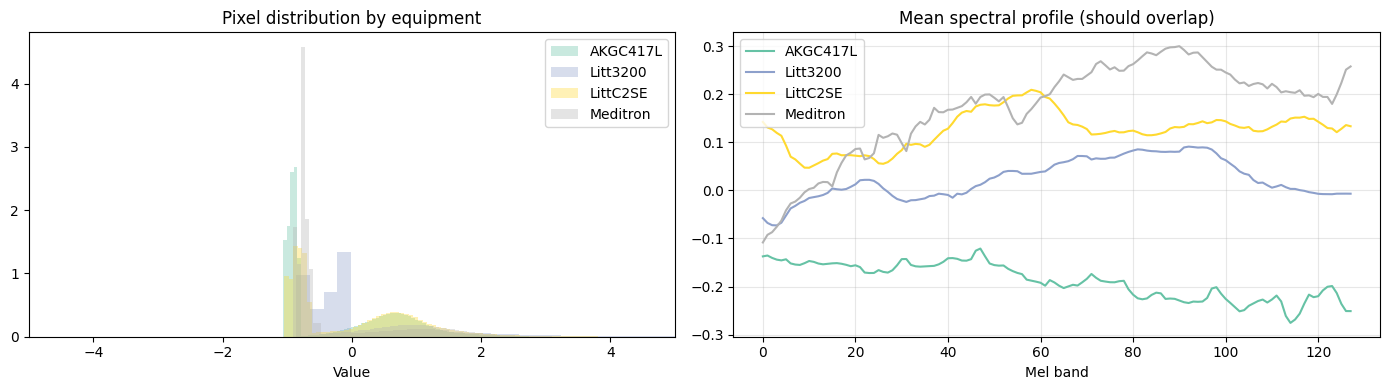

In [21]:
# equipment bias check — do the different devices still look different after normalization?
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
colors = plt.cm.Set2(np.linspace(0, 1, len(equipment_types)))

for eq, col in zip(equipment_types, colors):
    sp = [c['spectrogram'][0].flatten() for c in all_cycles if c['equipment'] == eq][:40]
    if sp:
        axes[0].hist(np.concatenate(sp), bins=80, alpha=0.35, color=col, label=eq, density=True)
axes[0].set_xlim(-5, 5); axes[0].legend()
axes[0].set_xlabel('Value'); axes[0].set_title('Pixel distribution by equipment')

for eq, col in zip(equipment_types, colors):
    sp = [c['spectrogram'][0] for c in all_cycles if c['equipment'] == eq][:80]
    if sp:
        axes[1].plot(np.mean(sp, axis=0).mean(axis=1), label=eq, lw=1.5, color=col)
axes[1].legend(); axes[1].grid(True, alpha=0.3)
axes[1].set_xlabel('Mel band'); axes[1].set_title('Mean spectral profile (should overlap)')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'equipment_bias_check.png'), dpi=150)
plt.show()

---
## 7 — Visualize the 3-channel spectrograms

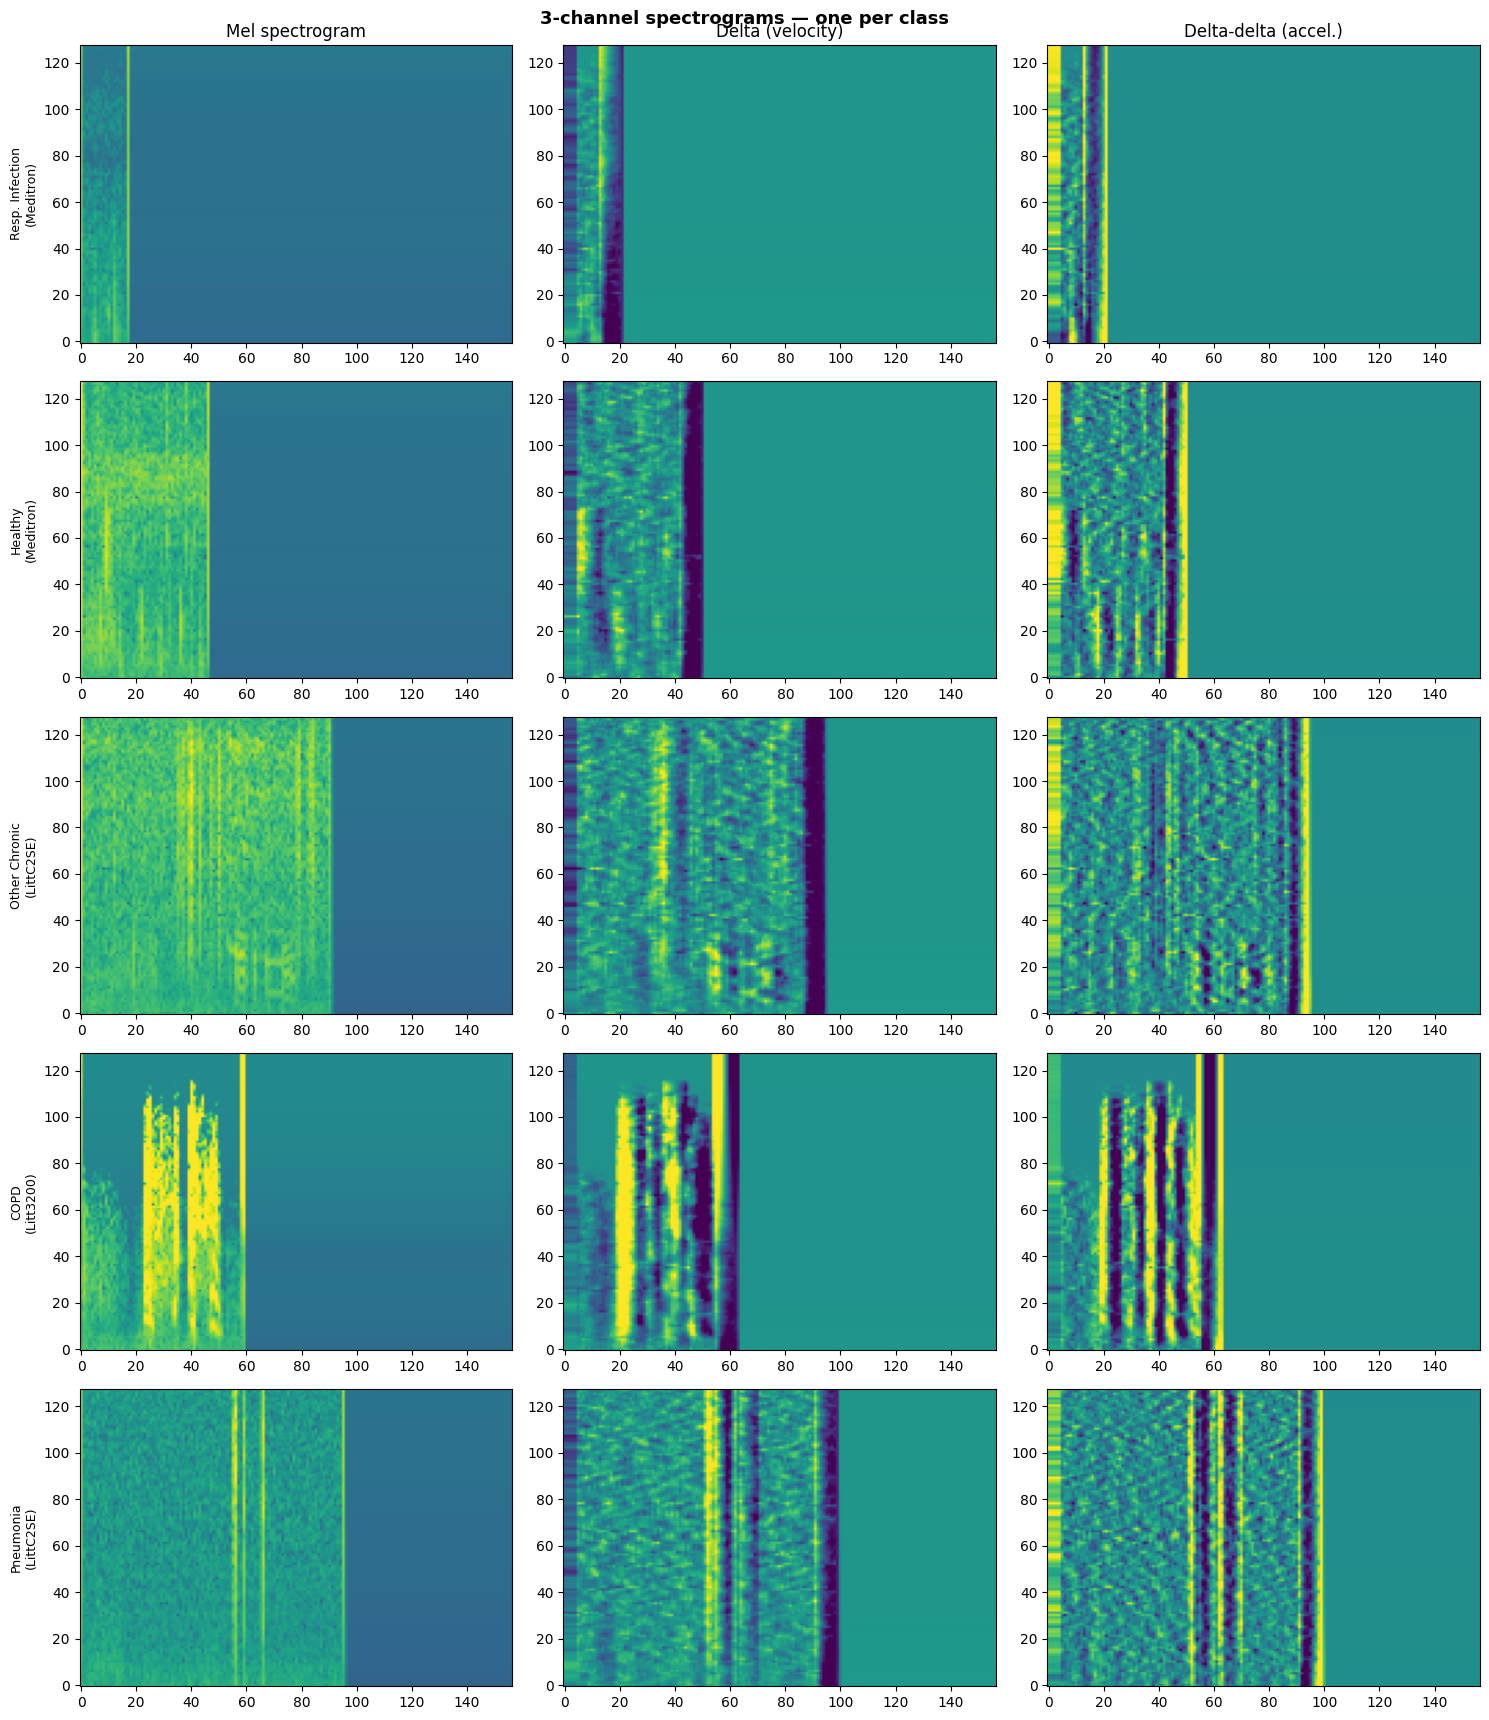

In [22]:
# pick one non-augmented sample from each class
shown = set()
samples = []
for c in all_cycles:
    if c['disease_class'] not in shown and not c['is_augmented']:
        samples.append(c)
        shown.add(c['disease_class'])
    if len(samples) >= 5:
        break

fig, axes = plt.subplots(len(samples), 3, figsize=(15, 3.5 * len(samples)))
ch_names = ['Mel spectrogram', 'Delta (velocity)', 'Delta-delta (accel.)']
for r, s in enumerate(samples):
    for ch in range(3):
        axes[r, ch].imshow(s['spectrogram'][ch], aspect='auto', origin='lower', cmap='viridis', vmin=-3, vmax=3)
        if r == 0: axes[r, ch].set_title(ch_names[ch])
        if ch == 0: axes[r, ch].set_ylabel(f"{s['disease_class']}\n({s['equipment']})", fontsize=9)

plt.suptitle('3-channel spectrograms — one per class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '3channel_spectrograms.png'), dpi=150)
plt.show()

---
## 8 — Labels, class weights, and distribution plots

In [23]:
# label encoding
unique_labels = sorted(set(c['disease_class'] for c in all_cycles))
label_to_idx = {l: i for i, l in enumerate(unique_labels)}
idx_to_label = {i: l for l, i in label_to_idx.items()}
num_classes = len(unique_labels)

# class weights based on training set
train_labels_arr = np.array([c['disease_class'] for c in train_cycles])
cw = compute_class_weight('balanced', classes=np.array(unique_labels), y=train_labels_arr)
class_weight_dict = {label_to_idx[l]: float(w) for l, w in zip(unique_labels, cw)}

print(f'Classes: {num_classes}\n')
print(f'{"Class":20s} {"Idx":>4s} {"Train":>8s} {"Val":>8s} {"Test":>8s} {"Weight":>8s}')
print('-' * 55)
for l in unique_labels:
    tr = sum(1 for c in train_cycles if c['disease_class'] == l)
    va = sum(1 for c in val_cycles if c['disease_class'] == l)
    te = sum(1 for c in test_cycles if c['disease_class'] == l)
    w = class_weight_dict[label_to_idx[l]]
    print(f'{l:20s} {label_to_idx[l]:4d} {tr:8d} {va:8d} {te:8d} {w:8.3f}')

Classes: 5

Class                 Idx    Train      Val     Test   Weight
-------------------------------------------------------
COPD                    0     4309      769      668    0.277
Healthy                 1      478       56       27    2.494
Other Chronic           2      402       36       33    2.965
Pneumonia               3      414       26       52    2.879
Resp. Infection         4      357       77       79    3.339


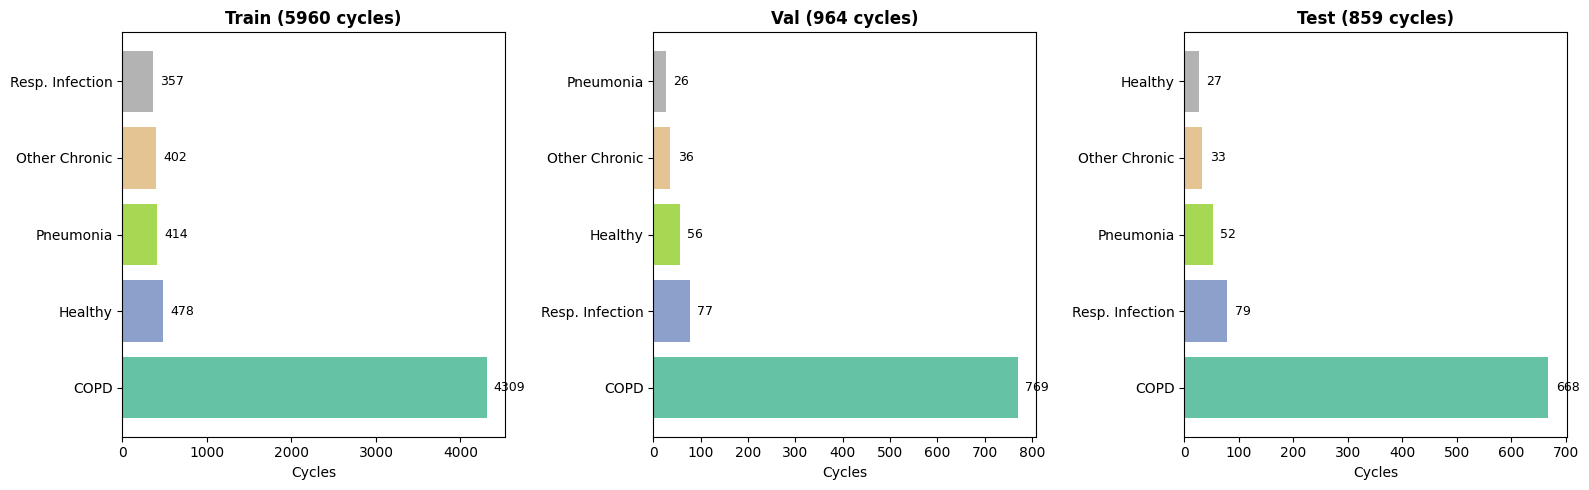

In [24]:
# show class distribution in each split
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (name, cycles) in zip(axes, [('Train', train_cycles), ('Val', val_cycles), ('Test', test_cycles)]):
    dist = Counter(c['disease_class'] for c in cycles)
    labels = sorted(dist.keys(), key=lambda x: -dist[x])
    vals = [dist[l] for l in labels]
    ax.barh(labels, vals, color=plt.cm.Set2(np.linspace(0, 1, len(labels))))
    ax.set_title(f'{name} ({sum(vals)} cycles)', fontweight='bold')
    ax.set_xlabel('Cycles')
    for bar, v in zip(ax.patches, vals):
        ax.text(bar.get_width() + max(vals)*0.02, bar.get_y() + bar.get_height()/2, str(v), va='center', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'class_distribution.png'), dpi=150)
plt.show()

---
## 9 — Save everything

In [25]:
def pack(cycles, label_to_idx):
    """turn cycle list into numpy arrays for saving"""
    return (
        np.array([c['spectrogram'] for c in cycles], dtype=np.float32),
        np.array([label_to_idx[c['disease_class']] for c in cycles], dtype=np.int64),
        np.array([c['patient_id'] for c in cycles], dtype=np.int32),
        np.array([c['crackle'] for c in cycles], dtype=np.int32),
        np.array([c['wheeze'] for c in cycles], dtype=np.int32),
        np.array([c['is_augmented'] for c in cycles], dtype=np.bool_),
        np.array([c['equipment'] for c in cycles]),
    )

print('Packing arrays...')
X_tr, y_tr, pid_tr, crk_tr, whz_tr, aug_tr, eq_tr = pack(train_cycles, label_to_idx)
X_va, y_va, pid_va, crk_va, whz_va, aug_va, eq_va = pack(val_cycles, label_to_idx)
X_te, y_te, pid_te, crk_te, whz_te, aug_te, eq_te = pack(test_cycles, label_to_idx)

print(f'  Train: {X_tr.shape}')
print(f'  Val:   {X_va.shape}')
print(f'  Test:  {X_te.shape}')

Packing arrays...
  Train: (5960, 3, 128, 157)
  Val:   (964, 3, 128, 157)
  Test:  (859, 3, 128, 157)


In [26]:
# save .npz files
print('Saving...')
for name, X, y, pids, crk, whz, aug, eq in [
    ('train', X_tr, y_tr, pid_tr, crk_tr, whz_tr, aug_tr, eq_tr),
    ('val',   X_va, y_va, pid_va, crk_va, whz_va, aug_va, eq_va),
    ('test',  X_te, y_te, pid_te, crk_te, whz_te, aug_te, eq_te),
]:
    path = os.path.join(OUTPUT_DIR, f'{name}_data.npz')
    np.savez_compressed(path, spectrograms=X, disease_labels=y,
                        patient_ids=pids, crackle_labels=crk, wheeze_labels=whz,
                        is_augmented=aug, equipment=eq)
    mb = os.path.getsize(path) / (1024**2)
    print(f'  {name}_data.npz: {mb:.1f} MB')

# save normalization stats (needed at inference time)
norm_data = {'global_mean': global_mean, 'global_std': global_std}
for eq, (m, s) in equip_stats.items():
    norm_data[f'{eq}_mean'] = m
    norm_data[f'{eq}_std'] = s
np.savez(os.path.join(OUTPUT_DIR, 'norm_stats.npz'), **norm_data)
print('  norm_stats.npz')

# save metadata
metadata = {
    'label_to_idx': label_to_idx,
    'idx_to_label': {str(k): v for k, v in idx_to_label.items()},
    'num_classes': num_classes,
    'class_weights': {str(k): v for k, v in class_weight_dict.items()},
    'class_grouping': CLASS_GROUPING,
    'target_sr': TARGET_SR,
    'cycle_duration_s': float(CYCLE_DURATION),
    'n_mels': N_MELS, 'n_fft': N_FFT, 'hop_length': HOP_LENGTH,
    'f_min': F_MIN, 'f_max': F_MAX,
    'n_channels': 3,
    'spectrogram_shape': list(spec_shape),
    'min_cycles_per_class': MIN_CYCLES_PER_CLASS,
    'augmentation_multipliers': {k: int(v) for k, v in aug_multiplier.items()},
    'normalization': 'per_equipment_per_band_zscore',
    'equipment_types': equipment_types,
    'train_patients': sorted([int(p) for p in train_set]),
    'val_patients': sorted([int(p) for p in val_set]),
    'test_patients': sorted([int(p) for p in test_set]),
    'n_train': len(train_cycles),
    'n_val': len(val_cycles),
    'n_test': len(test_cycles),
}
with open(os.path.join(OUTPUT_DIR, 'metadata.json'), 'w') as f:
    json.dump(metadata, f, indent=2)
print('  metadata.json')

print(f'\nAll saved to {OUTPUT_DIR}')

Saving...
  train_data.npz: 644.1 MB
  val_data.npz: 115.6 MB
  test_data.npz: 105.1 MB
  norm_stats.npz
  metadata.json

All saved to /content/drive/MyDrive/ICBHI_preprocessed/


---
## 10 — Final good checks

In [28]:
# reload from disk and verify everything
tr = np.load(os.path.join(OUTPUT_DIR, 'train_data.npz'))
va = np.load(os.path.join(OUTPUT_DIR, 'val_data.npz'))
te = np.load(os.path.join(OUTPUT_DIR, 'test_data.npz'))
with open(os.path.join(OUTPUT_DIR, 'metadata.json')) as f:
    meta = json.load(f)

print('=' * 60)
print('Final CHECK')
print('=' * 60)

# shapes
print(f'\n1. Shapes')
print(f'   Train: {tr["spectrograms"].shape}')
print(f'   Val:   {va["spectrograms"].shape}')
print(f'   Test:  {te["spectrograms"].shape}')

# normalization
print(f'\n2. Normalization (training set)')
for ch, name in enumerate(['Mel', 'Delta', 'Delta-delta']):
    m = tr['spectrograms'][:, ch].mean()
    s = tr['spectrograms'][:, ch].std()
    print(f'   Ch{ch} {name:12s}: mean={m:+.4f}, std={s:.4f}')

# per-equipment
print(f'\n3. Per-equipment normalization')
for eq in equipment_types:
    mask = tr['equipment'] == eq
    if mask.sum() > 0:
        m = tr['spectrograms'][mask][:, 0].mean()
        s = tr['spectrograms'][mask][:, 0].std()
        print(f'   {eq:15s}: mean={m:+.4f}, std={s:.4f}')

# augmentation
print(f'\n4. Augmentation')
n_aug = tr['is_augmented'].sum()
n_orig = len(tr['is_augmented']) - n_aug
print(f'   Original: {n_orig} | Augmented: {n_aug} | Total: {n_orig + n_aug}')

# labels
print(f'\n5. Label distribution')
for nm, data in [('Train', tr), ('Val', va), ('Test', te)]:
    dist = Counter(data['disease_labels'])
    parts = [f"{meta['idx_to_label'][str(k)]}={v}" for k, v in sorted(dist.items())]
    print(f'   {nm:5s} ({len(data["disease_labels"]):5d}): {" | ".join(parts)}')

# all 5 classes present
print(f'\n6. All 5 classes present?')
for nm, data in [('Train', tr), ('Val', va), ('Test', te)]:
    n_cls = len(set(data['disease_labels']))
    print(f'   {nm}: {n_cls} classes {"✓" if n_cls == 5 else "✗ MISSING CLASSES"}')

# no leakage
print(f'\n7. Patient leakage check')
tp, vp, tep = set(tr['patient_ids']), set(va['patient_ids']), set(te['patient_ids'])
leak = len(tp & vp) + len(tp & tep) + len(vp & tep)
print(f'   Overlaps: {leak} (must be 0) → {"PASS ✓" if leak == 0 else "FAIL ✗"}')

# files
print(f'\n8. Saved files')
for fn in sorted(os.listdir(OUTPUT_DIR)):
    fp = os.path.join(OUTPUT_DIR, fn)
    if os.path.isfile(fp):
        print(f'   {fn}: {os.path.getsize(fp)/(1024**2):.1f} MB')

# class weights
print(f'\n9. Class weights')
for i in range(num_classes):
    print(f'   {meta["idx_to_label"][str(i)]:20s}: {meta["class_weights"][str(i)]:.3f}')

print(f'\n10. Config')
for k in ['target_sr', 'cycle_duration_s', 'n_mels', 'n_fft', 'hop_length',
          'f_min', 'f_max', 'n_channels', 'normalization', 'num_classes']:
    print(f'   {k}: {meta[k]}')

print('\n' + '=' * 60)
print('READY FOR TRAINING')
print('=' * 60)

Final CHECK

1. Shapes
   Train: (5960, 3, 128, 157)
   Val:   (964, 3, 128, 157)
   Test:  (859, 3, 128, 157)

2. Normalization (training set)
   Ch0 Mel         : mean=-0.0000, std=1.0000
   Ch1 Delta       : mean=-0.0000, std=1.0000
   Ch2 Delta-delta : mean=+0.0000, std=1.0000

3. Per-equipment normalization
   AKGC417L       : mean=-0.0000, std=1.0000
   Litt3200       : mean=+0.0000, std=1.0000
   LittC2SE       : mean=-0.0000, std=1.0000
   Meditron       : mean=-0.0000, std=1.0000

4. Augmentation
   Original: 5075 | Augmented: 885 | Total: 5960

5. Label distribution
   Train ( 5960): COPD=4309 | Healthy=478 | Other Chronic=402 | Pneumonia=414 | Resp. Infection=357
   Val   (  964): COPD=769 | Healthy=56 | Other Chronic=36 | Pneumonia=26 | Resp. Infection=77
   Test  (  859): COPD=668 | Healthy=27 | Other Chronic=33 | Pneumonia=52 | Resp. Infection=79

6. All 5 classes present?
   Train: 5 classes ✓
   Val: 5 classes ✓
   Test: 5 classes ✓

7. Patient leakage check
   Overlaps

---
## 11 — PyTorch Dataset class (for use in training notebook)

Copy this into your training notebook. It handles SpecAugment on-the-fly.

In [29]:
import torch
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler


def spec_augment(spec_3ch, n_freq=1, freq_w=12, n_time=1, time_w=20):
    """mask random frequency and time bands across all 3 channels"""
    aug = spec_3ch.copy()
    _, n_mels, n_frames = aug.shape
    for _ in range(n_freq):
        f = np.random.randint(1, min(freq_w, n_mels))
        f0 = np.random.randint(0, n_mels - f)
        aug[:, f0:f0+f, :] = 0.0
    for _ in range(n_time):
        t = np.random.randint(1, min(time_w, n_frames))
        t0 = np.random.randint(0, n_frames - t)
        aug[:, :, t0:t0+t] = 0.0
    return aug


class ICBHIDataset(Dataset):
    def __init__(self, npz_path, augment=False):
        data = np.load(npz_path)
        self.specs = data['spectrograms']     # (N, 3, 128, T)
        self.labels = data['disease_labels']   # (N,)
        self.augment = augment

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        spec = self.specs[idx].copy()
        if self.augment:
            spec = spec_augment(spec)
        return torch.FloatTensor(spec), torch.tensor(self.labels[idx], dtype=torch.long)


def mixup_data(x, y, alpha=0.3):
    """blend two random samples together — soft labels help with generalization"""
    if alpha <= 0:
        return x, y, y, 1.0
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(x.size(0)).to(x.device)
    return lam * x + (1 - lam) * x[idx], y, y[idx], lam


# quick smoke test
ds = ICBHIDataset(os.path.join(OUTPUT_DIR, 'train_data.npz'), augment=True)
x, y = ds[0]
print(f'Sample: x={x.shape}, y={y.item()} ({idx_to_label[y.item()]})')
print(f'Input shape for model: (batch, {x.shape[0]}, {x.shape[1]}, {x.shape[2]})')
print(f'Output classes: {num_classes}')

Sample: x=torch.Size([3, 128, 157]), y=1 (Healthy)
Input shape for model: (batch, 3, 128, 157)
Output classes: 5
